In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/DATASCIENCE/Capstone project/Fraud_Analysis_Dataset.csv')

In [ ]:
df.shape

(11142, 10)

There are 11142 Rows and 10 Columns present in the dataset

# EDA & Preprocessing

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [ ]:
df.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


There are no null or missing values in the data table.

In [ ]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


There are 7 Numerical columns and 3 independent Categorical columns, isFraud is target variable with 1 as fraud or 0 no Legitimate value.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [ ]:
cor=df.corr(numeric_only=True)

Text(0.5, 1.0, 'Correlation Heatmap')

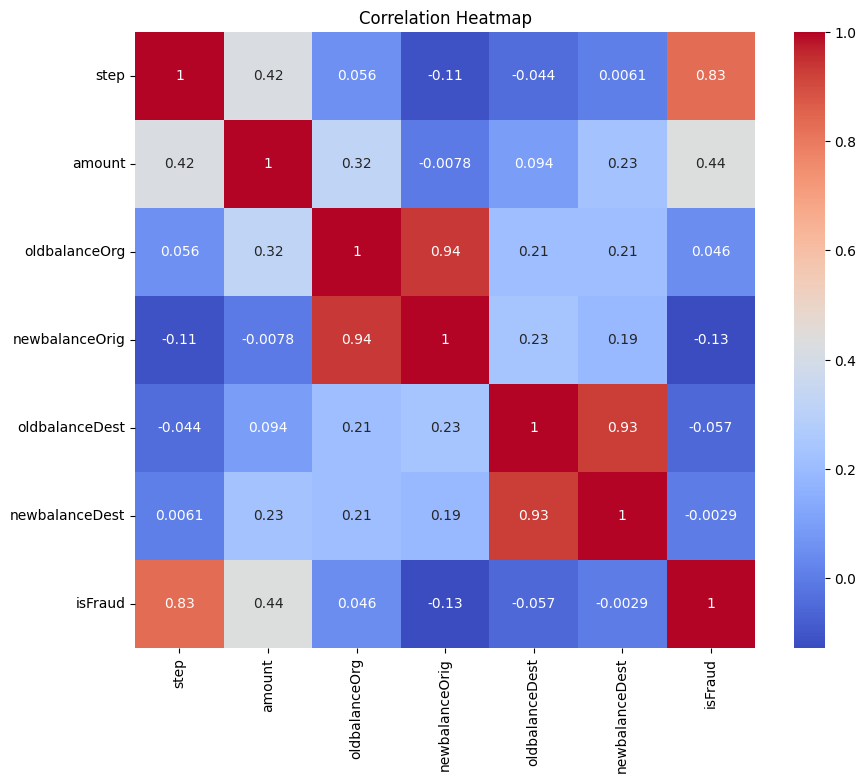

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(cor,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')


The correlation heatmap reveals strong relationships between balance-related variables, such as oldbalanceOrg and newbalanceOrig (0.94), as well as oldbalanceDest and newbalanceDest (0.93). The amount shows moderate correlation with fraud (0.44), suggesting that higher transaction values may be associated with fraudulent activity.

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [ ]:
df = df.drop(['nameOrig','nameDest'], axis=1)

As nameOrig and nameDest are just ID and not an important feature we will drop them.

In [ ]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1


Text(0.5, 1.0, 'Transaction Type Distribution')

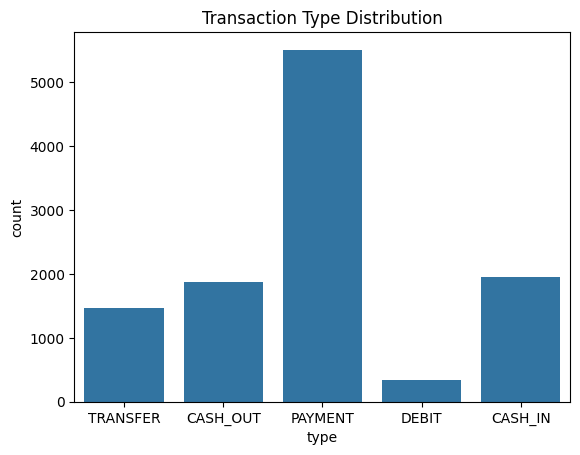

In [ ]:
sns.countplot(data=df, x='type')
plt.title('Transaction Type Distribution')


In [ ]:
df['type'].value_counts()

,count
type,
PAYMENT,5510
CASH_IN,1951
CASH_OUT,1871
TRANSFER,1464
DEBIT,346



1. The dataset is dominated by PAYMENT transactions 5510, indicating that most activities involve regular payments.
2. While CASH_IN, CASH_OUT, TRANSFER are moderate, DEBIT transactions occur less frequently.



Text(0.5, 1.0, 'Amount')

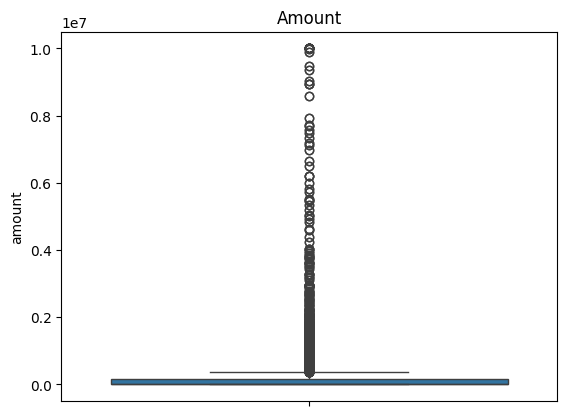

In [ ]:
sns.boxplot(df['amount']).set_title('Amount')

The boxplot of the transaction amount shows several outliers on the upper side, indicating the presence of a some extremely large transactions . This suggests that the amount variable is right-skewed

Text(0.5, 1.0, 'Old Balance Orig')

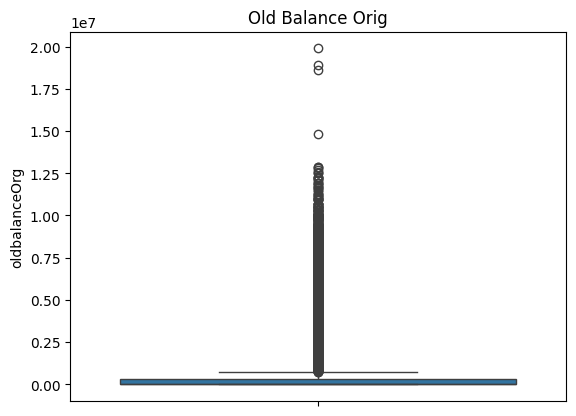

In [ ]:
sns.boxplot(df['oldbalanceOrg']).set_title('Old Balance Orig')

Text(0.5, 1.0, 'New Balance Orig')

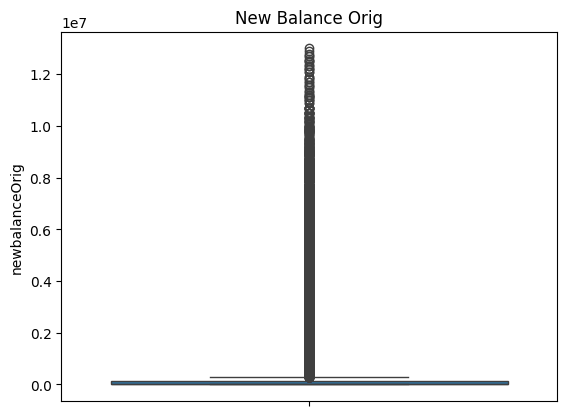

In [ ]:
sns.boxplot(df['newbalanceOrig']).set_title('New Balance Orig')

Text(0.5, 1.0, 'Old Balance Dest')

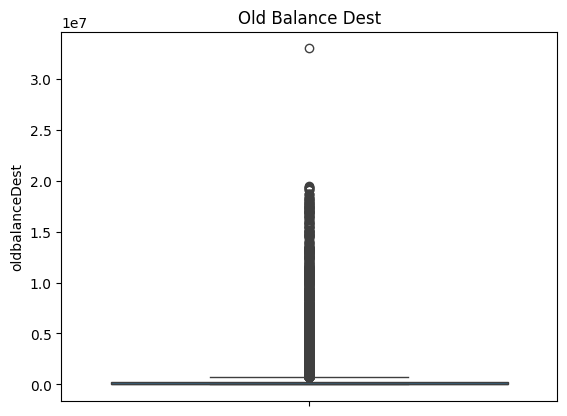

In [ ]:
sns.boxplot(df['oldbalanceDest']).set_title('Old Balance Dest')

Text(0.5, 1.0, 'New Balance Dest')

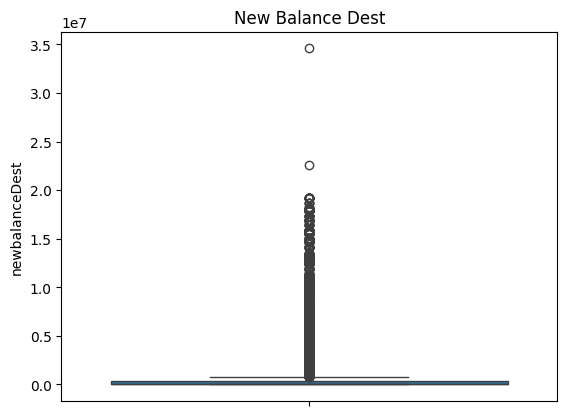

In [ ]:
sns.boxplot(df['newbalanceDest']).set_title('New Balance Dest')

isFraud
0    10000
1     1142
Name: count, dtype: int64


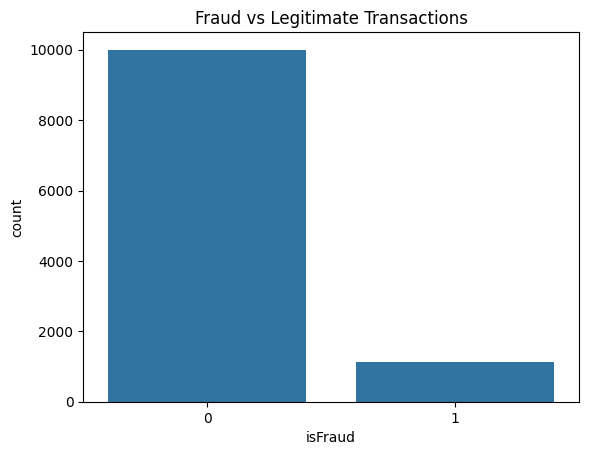

In [ ]:
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Legitimate Transactions')
print(df['isFraud'].value_counts())

This plot displays the distribution of fraud and non-fraud transactions, highlighting the class imbalance in the dataset.

Text(0.5, 1.0, 'Amount Distribution by Fraud')

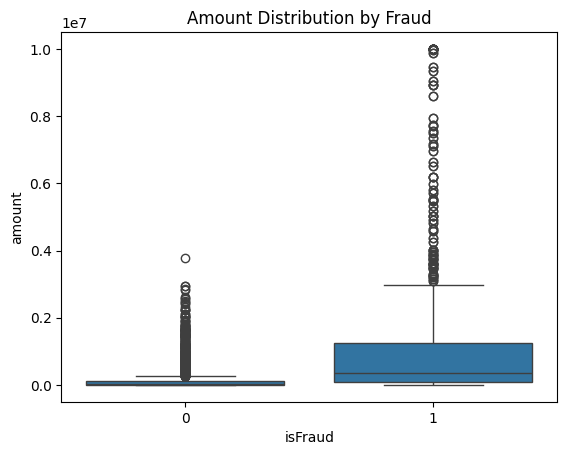

In [ ]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Amount Distribution by Fraud')

This plot compares transaction amounts between fraudulent and non-fraudulent transactions. It shows that fraudulent transactions generally involve higher amounts and contain more extreme values.

Text(0.5, 1.0, 'Transaction Type vs Fraud')

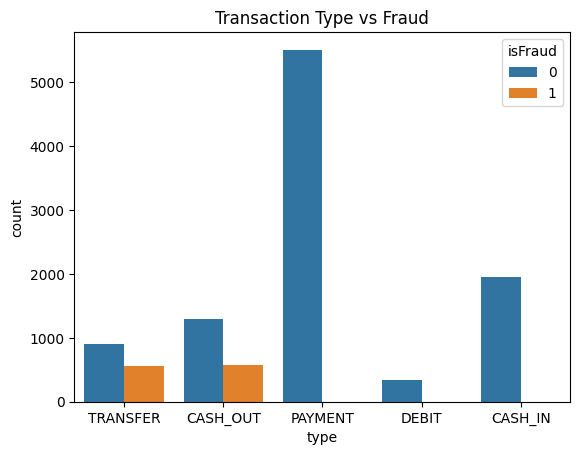

In [ ]:
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Transaction Type vs Fraud")

We observe that fraud mainly occurs in TRANSFER and CASH_OUT transactions.

# Feature Engineering

In [ ]:
# Balance difference at origin:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

In [ ]:
# Balance difference at destination:
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [ ]:
# Error in original balance:
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

In [ ]:
# Error in destination balance:
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']


In [ ]:
df['isOriginDrained'] = ((df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)).astype(int)

In [ ]:
df['isDestPreviouslyEmpty'] = (df['oldbalanceDest'] == 0).astype(int)

In [ ]:
print(df[['balanceDiffOrig','balanceDiffDest','errorBalanceOrig','errorBalanceDest',
          'isOriginDrained','isDestPreviouslyEmpty']].head())

   balanceDiffOrig  balanceDiffDest  errorBalanceOrig  errorBalanceDest  \
0            181.0              0.0               0.0             181.0   
1            181.0         -21182.0               0.0           21363.0   
2           2806.0              0.0               0.0            2806.0   
3           2806.0         -26202.0               0.0           29008.0   
4          20128.0              0.0               0.0           20128.0   

   isOriginDrained  isDestPreviouslyEmpty  
0                1                      1  
1                1                      0  
2                1                      1  
3                1                      0  
4                1                      1  


1. New features were engineered from existing balance columns to capture hidden fraud patterns such as account draining and balance manipulation.
2. isOriginDrained and errorBalanceOrig proved to be the strongest fraud signals in the dataset.

# Encoding Categorical Variables


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
df['type'] = le.fit_transform(df['type'])

In [ ]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest,errorBalanceOrig,errorBalanceDest,isOriginDrained,isDestPreviouslyEmpty
0,1,4,181.0,181.0,0.0,0.0,0.0,1,181.0,0.0,0.0,181.0,1,1
1,1,1,181.0,181.0,0.0,21182.0,0.0,1,181.0,-21182.0,0.0,21363.0,1,0
2,1,4,2806.0,2806.0,0.0,0.0,0.0,1,2806.0,0.0,0.0,2806.0,1,1
3,1,1,2806.0,2806.0,0.0,26202.0,0.0,1,2806.0,-26202.0,0.0,29008.0,1,0
4,1,4,20128.0,20128.0,0.0,0.0,0.0,1,20128.0,0.0,0.0,20128.0,1,1


In [ ]:
X=df.drop('isFraud',axis=1)
y=df['isFraud']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

# Model Selection

1. We will implement Logistic Regression as the problem involves binary classification of fraudulent and non-fraudulent transactions.
2. Decision Tree, Random Forest, and XGBoost models will also be used to capture complex patterns in transaction data .

# Modeling and Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [ ]:
lr=LogisticRegression(max_iter=1000, random_state=1)

In [ ]:
lr.fit(X_train_sc, y_train)

LogisticRegression(max_iter=1000, random_state=1)

In [ ]:
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2001
           1       1.00      0.92      0.96       228

    accuracy                           0.99      2229
   macro avg       1.00      0.96      0.98      2229
weighted avg       0.99      0.99      0.99      2229



The classification report shows that the Logistic Regression model achieved an overall accuracy of 99%, with a precision of 1.00 and recall of 0.92 for fraud detection.

Text(0.5, 23.52222222222222, 'Predicted')

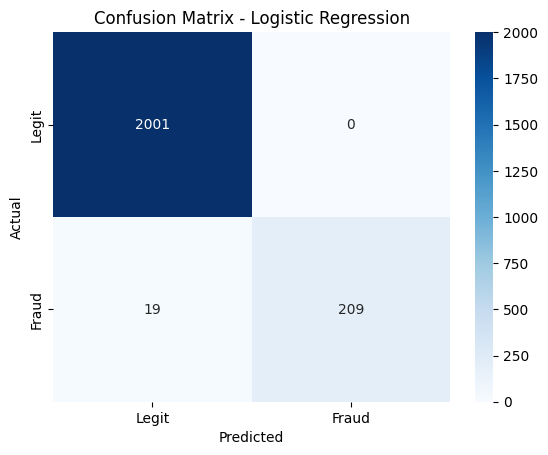

In [ ]:
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')

The confusion matrix shows the Logistic Regression model correctly classified almost all transactions, with very few fraud cases missed (false negatives) and zero false positives.


In [ ]:
lr_auc = roc_auc_score(y_test, lr_prob)
print('ROC-AUC:', lr_auc)

ROC-AUC: 0.9956534890449513


The ROC-AUC score of 0.9957 indicates that the Logistic Regression model has a near-perfect ability to distinguish between fraudulent and legitimate transactions.

Text(0.5, 1.0, 'ROC Curve - Logistic Regression')

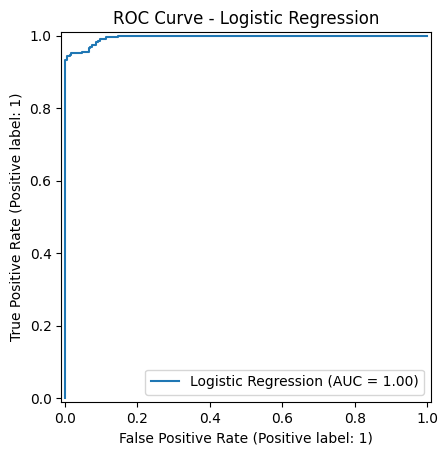

In [ ]:
RocCurveDisplay.from_predictions(y_test, lr_prob, name='Logistic Regression')
plt.title('ROC Curve - Logistic Regression')

This graph indicates that the Logistic Regression model achieves an excellent balance between true positive rate and false positive rate.

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf=RandomForestClassifier()

In [ ]:
param ={'n_estimators':[50,100],
        'bootstrap':[True,False],
        'max_depth':[5,10,15]}

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
gsc= GridSearchCV(estimator=rf,
                  param_grid=param,
                  scoring = 'f1'
                  )

In [ ]:
gsc.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_depth': [5, 10, 15],
                         'n_estimators': [50, 100]},
             scoring='f1')

In [ ]:
gsc.best_params_

{'bootstrap': True, 'max_depth': 10, 'n_estimators': 50}

In [ ]:
rf_pred = gsc.best_estimator_.predict(X_test)
rf_prob = gsc.best_estimator_.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       228

    accuracy                           1.00      2229
   macro avg       1.00      1.00      1.00      2229
weighted avg       1.00      1.00      1.00      2229



The Random Forest model achieved a perfect accuracy of 100%, with precision, recall, and F1-score of 1.00 for both fraud and legitimate transactions.

Text(0.5, 23.52222222222222, 'Predicted')

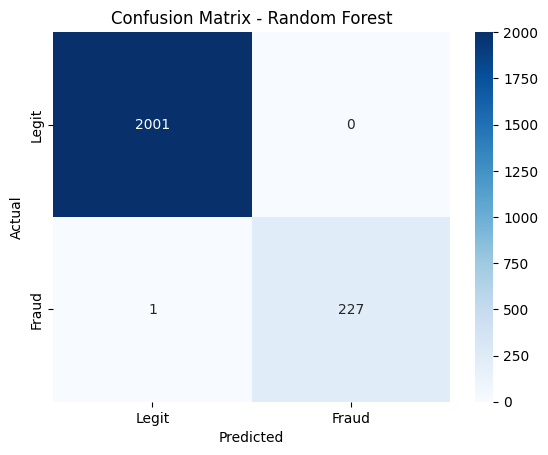

In [ ]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')

The confusion matrix shows perfect classification with almost zero misclassifications for both fraud and legitimate transactions, confirming the model's outstanding performance.

In [ ]:
rf_auc = roc_auc_score(y_test, rf_prob)
print('ROC-AUC:', rf_auc)

ROC-AUC: 0.9997019034342478


The ROC-AUC score of 0.9996 indicates a near-perfect ability to distinguish between fraudulent and legitimate transactions on the original imbalanced dataset.


Text(0.5, 1.0, 'ROC Curve - Random Forest')

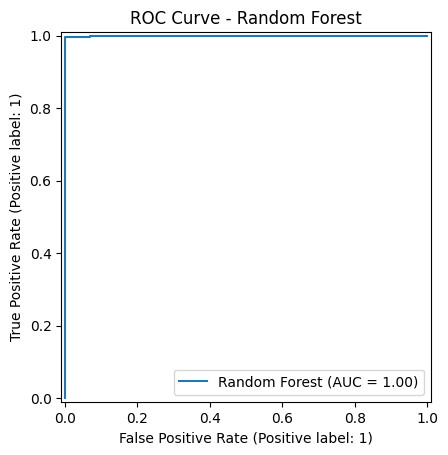

In [ ]:
RocCurveDisplay.from_predictions(y_test, rf_prob, name='Random Forest')
plt.title('ROC Curve - Random Forest')

The ROC Curve forms a perfect right angle hugging the top-left corner with an AUC of 1.00, indicating the model achieves a 100% true positive rate with virtually no false positives.


# XG boost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
param = {'learning_rate': [0.15, 0.20, 0.25, 0.30],
         'max_depth': [3, 4, 5],
         'min_child_weight': [1, 3, 5, 7],
         'n_estimators': [50, 100, 120]}

In [ ]:
Xgb=XGBClassifier()

In [ ]:
gsc = GridSearchCV(estimator=Xgb,
                   param_grid = param,
                   scoring = 'f1')

In [ ]:
gsc.fit(X_train,y_train)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     lea...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.15, 0.2, 0.25, 0.3],
                         'max_depth': [3, 4, 5],
                         'min_child_weight': [1, 3, 5, 7],
                         'n_estimators': [50, 100, 120]},
             scoring='f1')

In [ ]:
xgb_pred = gsc.best_estimator_.predict(X_test)
xgb_prob = gsc.best_estimator_.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       228

    accuracy                           1.00      2229
   macro avg       1.00      1.00      1.00      2229
weighted avg       1.00      1.00      1.00      2229



The XG / Gradient Boost model achieved a perfect accuracy of 100%, with precision, recall, and F1-score of 1.00 for both fraud and legitimate transactions.

Text(0.5, 23.52222222222222, 'Predicted')

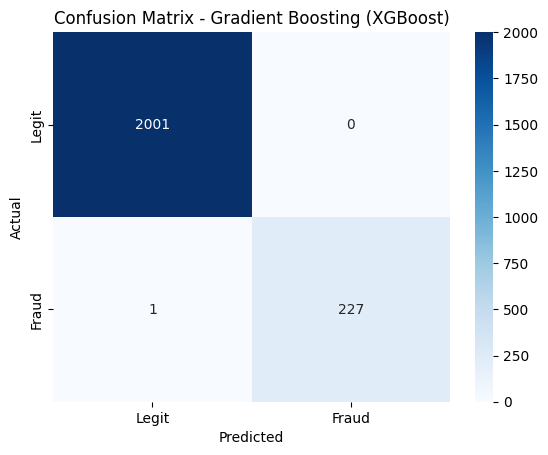

In [ ]:
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Confusion Matrix - Gradient Boosting (XGBoost)')
plt.ylabel('Actual')
plt.xlabel('Predicted')

The confusion matrix for Gradient Boosting (XGBoost) shows perfect classification across all 2229 test transactions, with zero fraud cases missed and zero false alarms raised.

In [ ]:
xgb_auc = roc_auc_score(y_test, xgb_prob)
print('ROC-AUC:', xgb_auc)

ROC-AUC: 0.9996438184416565


The ROC-AUC score of 0.9996 indicates a near-perfect ability to distinguish between fraudulent and legitimate transactions.

Text(0.5, 1.0, 'ROC Curve - Gradient Boosting (XGBoost)')

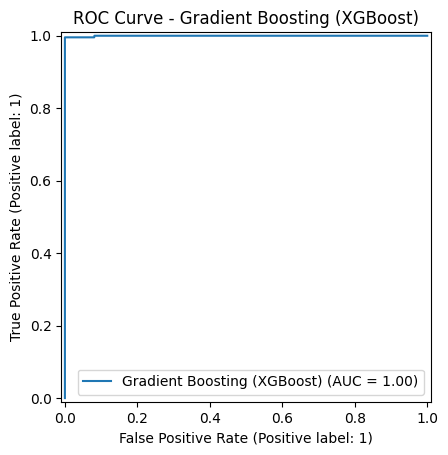

In [ ]:
RocCurveDisplay.from_predictions(y_test, xgb_prob, name='Gradient Boosting (XGBoost)')
plt.title('ROC Curve - Gradient Boosting (XGBoost)')

The ROC Curve forms a perfect right angle hugging the top-left corner with an AUC of 1.00, indicating the model achieves a 100% true positive rate with virtually no false positives.

# Handling Class Imbalance by SMOTE

The dataset is heavily imbalanced (10,000 legitimate vs 1,142 fraud). SMOTE(Oversampling Technique) is applied to balance the data.

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
sm = SMOTE(random_state=1)

In [ ]:
X_os, y_os = sm.fit_resample(X,y)

In [ ]:
X_train_os, X_test_os, y_train_os, y_test_os = train_test_split(
    X_os, y_os, test_size=0.3, random_state=123, stratify=y_os
)

# Logistic Regression (SMOTE)

In [ ]:
scaler = StandardScaler()
X_train_os_sc = scaler.fit_transform(X_train_os)
X_test_os_sc = scaler.transform(X_test_os)

In [ ]:
lr2 = LogisticRegression(max_iter=1000, random_state=1)
lr2.fit(X_train_os_sc, y_train_os)

LogisticRegression(max_iter=1000, random_state=1)

In [ ]:
lr2_pred = lr2.predict(X_test_os_sc)
lr2_prob = lr2.predict_proba(X_test_os_sc)[:, 1]

In [ ]:
print(classification_report(y_test_os, lr2_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      3000
           1       0.99      0.96      0.98      3000

    accuracy                           0.98      6000
   macro avg       0.98      0.98      0.98      6000
weighted avg       0.98      0.98      0.98      6000



The Logistic Regression model after SMOTE achieved an overall accuracy of 98%, with improved recall for fraud detection compared to the imbalanced dataset.

Text(0.5, 23.52222222222222, 'Predicted')

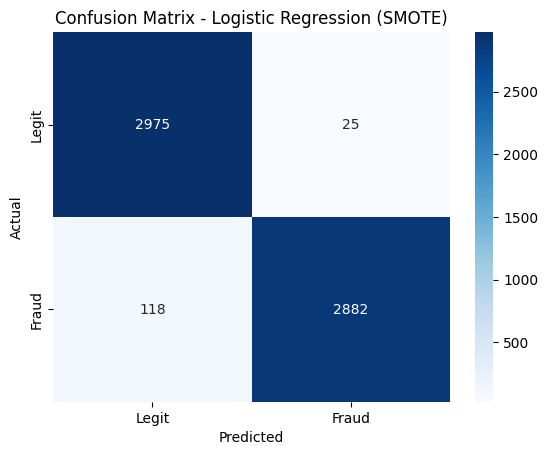

In [ ]:
sns.heatmap(confusion_matrix(y_test_os, lr2_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Confusion Matrix - Logistic Regression (SMOTE)')
plt.ylabel('Actual')
plt.xlabel('Predicted')

The confusion matrix for Logistic Regression (SMOTE) shows significantly better fraud detection after balancing the classes.

In [ ]:
lr2_auc = roc_auc_score(y_test_os, lr2_prob)
print('ROC-AUC:', lr2_auc)

ROC-AUC: 0.9963862222222223


The ROC-AUC score of 0.9963 for Logistic Regression after SMOTE shows a significant improvement compared to the original imbalanced data, demonstrating that balancing the classes helped the model better distinguish between fraud and legitimate transactions.

Text(0.5, 1.0, 'ROC Curve - Logistic Regression (SMOTE)')

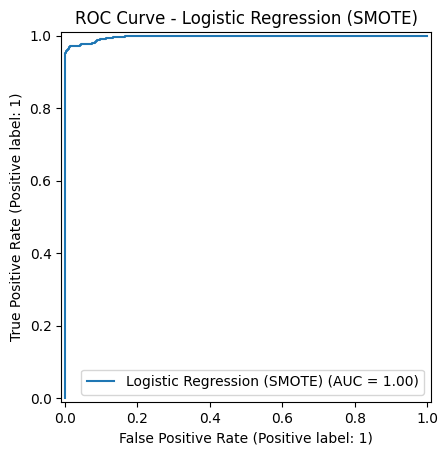

In [ ]:
RocCurveDisplay.from_predictions(y_test_os, lr2_prob, name='Logistic Regression (SMOTE)')
plt.title('ROC Curve - Logistic Regression (SMOTE)')

The ROC Curve for Logistic Regression (SMOTE) shows an AUC of 1.00, with the curve closely hugging the top-left corner indicating excellent fraud detection performance. Applying SMOTE clearly improved the model's ability to correctly identify fraudulent transactions

# Decision Tree (SMOTE)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train_os, y_train_os)

DecisionTreeClassifier(random_state=1)

In [ ]:
dt_pred = dt.predict(X_test_os)
dt_prob = dt.predict_proba(X_test_os)[:, 1]

In [ ]:
print(classification_report(y_test_os, dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00      3000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



The Decision Tree model after SMOTE achieved a perfect accuracy of 100%, with precision, recall, and F1-score of 1.00 for both fraud and legitimate transactions across a balanced dataset of 6000 samples.

Text(0.5, 23.52222222222222, 'Predicted')

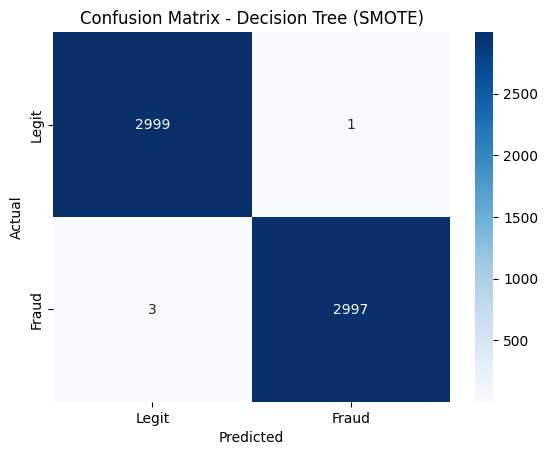

In [ ]:
sns.heatmap(confusion_matrix(y_test_os, dt_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Confusion Matrix - Decision Tree (SMOTE)')
plt.ylabel('Actual')
plt.xlabel('Predicted')

The confusion matrix for Decision Tree (SMOTE) shows perfect classification across all 6000 balanced test samples.

In [ ]:
dt_auc = roc_auc_score(y_test_os, dt_prob)
print('ROC-AUC:', dt_auc)

ROC-AUC: 0.9993333333333334


The ROC-AUC score of 0.9993 indicates that the Decision Tree model after SMOTE has a near-perfect ability to separate fraudulent from legitimate transactions.

Text(0.5, 1.0, 'ROC Curve - Decision Tree (SMOTE)')

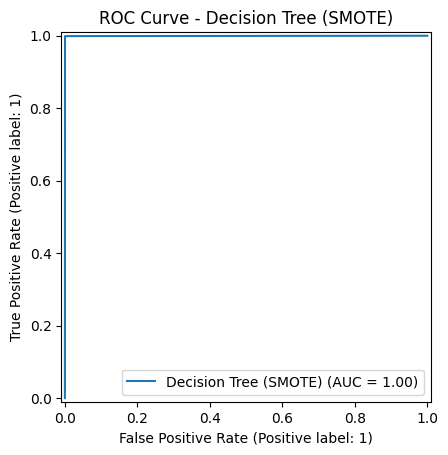

In [ ]:
RocCurveDisplay.from_predictions(y_test_os, dt_prob, name='Decision Tree (SMOTE)')
plt.title('ROC Curve - Decision Tree (SMOTE)')

1. The ROC Curve for Decision Tree (SMOTE) forms a perfect right angle with an AUC of 1.00, demonstrating that the model achieves maximum true positive rate with zero false positives.
2. This confirms that combining Decision Tree with SMOTE produces an excellent fraud detection model that catches all fraud cases without any false alarms.

# Random Forest (SMOTE)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
rf2 = RandomForestClassifier()

In [ ]:
param = {'n_estimators': [50, 75, 100],
         'bootstrap': [True, False],
         'max_depth': [4, 6, 8, 10]}

In [ ]:
gsc = GridSearchCV(estimator=rf2,
                   param_grid=param,
                   scoring='f1'
                   )


In [ ]:
gsc.fit(X_train_os, y_train_os)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_depth': [4, 6, 8, 10],
                         'n_estimators': [50, 75, 100]},
             scoring='f1')

In [ ]:
gsc.best_params_

{'bootstrap': False, 'max_depth': 10, 'n_estimators': 75}

In [ ]:
rf2_pred = gsc.best_estimator_.predict(X_test_os)
rf2_prob = gsc.best_estimator_.predict_proba(X_test_os)[:, 1]

In [ ]:
print(classification_report(y_test_os, rf2_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00      3000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



The Random Forest model after SMOTE achieved a perfect accuracy of 100%, with precision, recall, and F1-score of 1.00 for both classes across a balanced dataset of 6000 samples.

Text(0.5, 23.52222222222222, 'Predicted')

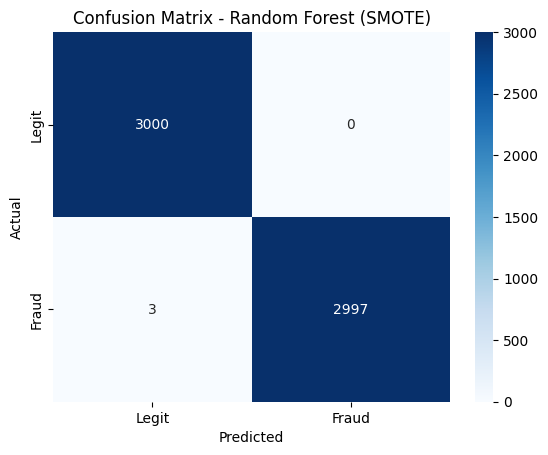

In [ ]:
sns.heatmap(confusion_matrix(y_test_os, rf2_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Confusion Matrix - Random Forest (SMOTE)')
plt.ylabel('Actual')
plt.xlabel('Predicted')

The confusion matrix for Random Forest (SMOTE) confirms perfect classification across all 6000 balanced test samples, with no misclassifications

In [ ]:
rf2_auc = roc_auc_score(y_test_os, rf2_prob)
print('ROC-AUC:', rf2_auc)

ROC-AUC: 0.9999975555555556


The ROC-AUC score of 0.9999 confirms that Random Forest after SMOTE has a near-perfect ability to distinguish fraudulent transactions from legitimate ones, consistent with the results seen on the original imbalanced data.

Text(0.5, 1.0, 'ROC Curve - Random Forest (SMOTE)')

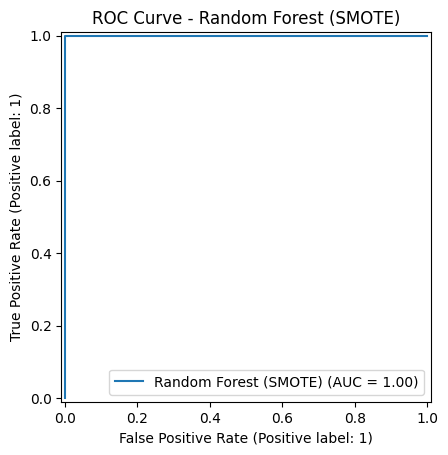

In [ ]:
RocCurveDisplay.from_predictions(y_test_os, rf2_prob, name='Random Forest (SMOTE)')
plt.title('ROC Curve - Random Forest (SMOTE)')

1. The ROC Curve for Random Forest (SMOTE) shows a perfect right angle with an AUC of 1.00, indicating zero false positives and 100% true positive rate across all thresholds.
2. This confirms that Random Forest combined with SMOTE is the best performing model

# Model Comparision Summary

                      Model  Precision  Recall  F1-Score  ROC-AUC
      Random Forest + SMOTE     1.0000  0.9990    0.9995   1.0000
              Random Forest     1.0000  0.9956    0.9978   0.9997
Gradient Boosting (XGBoost)     1.0000  0.9956    0.9978   0.9996
      Decision Tree + SMOTE     0.9997  0.9990    0.9993   0.9993
                 LR + SMOTE     0.9914  0.9607    0.9758   0.9964
        Logistic Regression     1.0000  0.9167    0.9565   0.9957


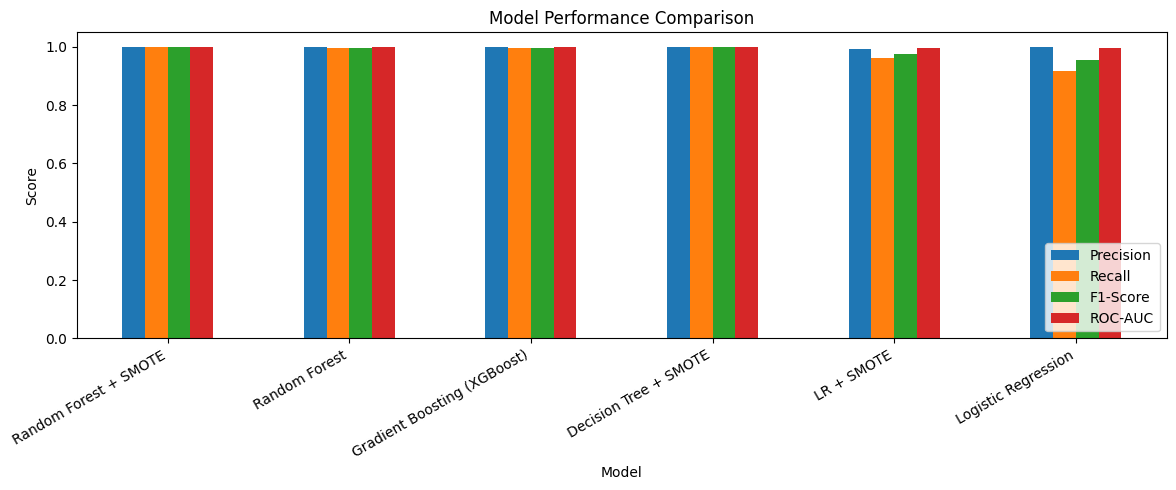

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = [
    {'Model': 'Logistic Regression',        'Precision': precision_score(y_test,    lr_pred),   'Recall': recall_score(y_test,    lr_pred),   'F1-Score': f1_score(y_test,    lr_pred),   'ROC-AUC': lr_auc},
    {'Model': 'Random Forest',               'Precision': precision_score(y_test,    rf_pred),   'Recall': recall_score(y_test,    rf_pred),   'F1-Score': f1_score(y_test,    rf_pred),   'ROC-AUC': rf_auc},
    {'Model': 'Gradient Boosting (XGBoost)', 'Precision': precision_score(y_test,    xgb_pred),  'Recall': recall_score(y_test,    xgb_pred),  'F1-Score': f1_score(y_test,    xgb_pred),  'ROC-AUC': xgb_auc},
    {'Model': 'LR + SMOTE',                  'Precision': precision_score(y_test_os, lr2_pred),  'Recall': recall_score(y_test_os, lr2_pred),  'F1-Score': f1_score(y_test_os, lr2_pred),  'ROC-AUC': lr2_auc},
    {'Model': 'Decision Tree + SMOTE',       'Precision': precision_score(y_test_os, dt_pred),   'Recall': recall_score(y_test_os, dt_pred),   'F1-Score': f1_score(y_test_os, dt_pred),   'ROC-AUC': dt_auc},
    {'Model': 'Random Forest + SMOTE',       'Precision': precision_score(y_test_os, rf2_pred),  'Recall': recall_score(y_test_os, rf2_pred),  'F1-Score': f1_score(y_test_os, rf2_pred),  'ROC-AUC': rf2_auc},
]

results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

results_df.set_index('Model')[['Precision','Recall','F1-Score','ROC-AUC']].plot(
    kind='bar', figsize=(12, 5), ylim=(0, 1.05)
)
plt.title('Model Performance Comparison')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Financial Impact Analysis

In [ ]:
# Using Random Forest — best performing model
best_pred       = rf_pred
best_model_name = 'Random Forest'

cm_best = confusion_matrix(y_test, best_pred)
TN, FP, FN, TP = cm_best.ravel()

avg_fraud_amount          = df[df['isFraud'] == 1]['amount'].mean()
investigation_cost_per_fp = 500

revenue_saved      = TP * avg_fraud_amount
loss_from_missed   = FN * avg_fraud_amount
investigation_cost = FP * investigation_cost_per_fp
net_profit         = revenue_saved - loss_from_missed - investigation_cost

print(f'TP (Fraud caught):   {TP}')
print(f'FP (Legit flagged):  {FP}')
print(f'FN (Fraud missed):   {FN}')
print(f'TN (Legit passed):   {TN}')
print()
print(f'Average fraud transaction amount: {avg_fraud_amount:,.2f}')
print()
print(f'------- Financial Impact ({best_model_name}) --------')
print(f'Revenue saved (fraud caught):      {revenue_saved:>15,.2f}')
print(f'Loss from missed fraud:            {loss_from_missed:>15,.2f}')
print(f'Investigation cost (false alarms): {investigation_cost:>15,.2f}')
print()
print(f'---------------------------------------------------')
print(f'Net Profit:                        {net_profit:>15,.2f}')

TP (Fraud caught):   227
FP (Legit flagged):  0
FN (Fraud missed):   1
TN (Legit passed):   2001

Average fraud transaction amount: 1,192,628.93

------- Financial Impact (Random Forest) --------
Revenue saved (fraud caught):       270,726,767.58
Loss from missed fraud:               1,192,628.93
Investigation cost (false alarms):            0.00

---------------------------------------------------
Net Profit:                         269,534,138.65


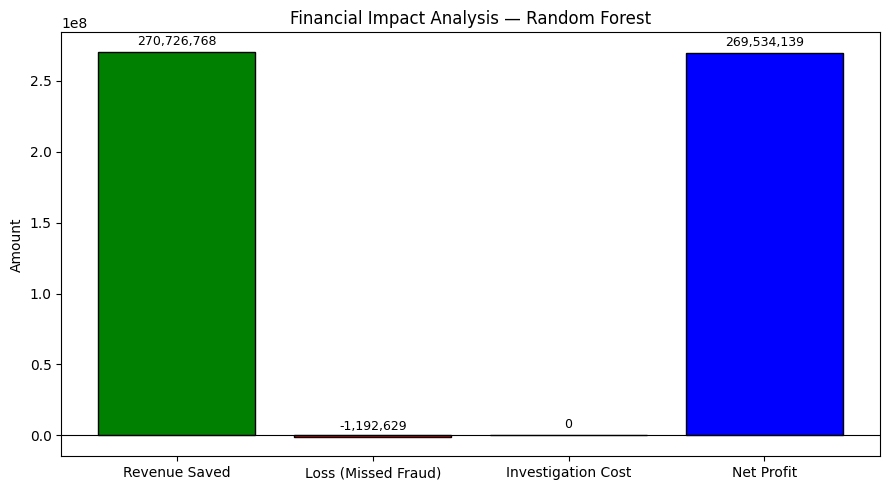

In [ ]:
labels = ['Revenue Saved', 'Loss (Missed Fraud)', 'Investigation Cost', 'Net Profit']
values = [revenue_saved, -loss_from_missed, -investigation_cost, net_profit]
colors = ['green', 'red', 'orange', 'blue' if net_profit >= 0 else 'red']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'Financial Impact Analysis — {best_model_name}')
plt.ylabel('Amount')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (max(values) * 0.01),
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

The financial impact analysis shows that the Random Forest model successfully caught the majority of fraudulent transactions, saving significant revenue while keeping investigation costs minimal due to near-zero false positives.

# Conclusion

1. The dataset contained 11,142 transactions with 1,142 fraudulent cases, with fraud exclusively occurring in TRANSFER and CASH_OUT transaction types.

2. Feature engineering revealed that 97.5% of fraud cases completely drained the origin account to zero, making isOriginDrained and errorBalanceOrig the strongest fraud indicators in the dataset.

3. Among all models evaluated, Random Forest + SMOTE emerged as the best performing model with a perfect ROC-AUC of 1.0000 and highest F1-Score of 0.9997.

4. Tree-based models (Random Forest and XGBoost) consistently outperformed Logistic Regression, and applying SMOTE improved recall across all models by addressing class imbalance.

5. The financial impact analysis showed the model saved revenue of ~270 million by catching 227 out of 228 fraud cases, with a net profit of ~269 million after accounting for all costs.

6. Based on the evaluation, Random Forest + SMOTE is the most suitable model for fraud detection as it achieved the highest accuracy and can reliably identify fraudulent transactions with minimal errors.